
# Lab 4: FDM-diffusion

Ross Anthony Miranda D'Angelo

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="400">

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.
2. Compare the *static solution* with the analytical one.
2. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.
3. Do a gif for the temperature in time (bonus!)

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import io
from PIL import Image
from IPython.display import display, Image as DisplayImage

## Parámetros iniciales

Para la ecuación de difusión

$$
\frac{\partial T}{\partial t}
=
D\left(
\frac{\partial^2 T}{\partial x^2}
+
\frac{\partial^2 T}{\partial y^2}
\right),
$$

usamos **diferencias finitas centrales en el espacio** y **hacia adelante en el tiempo**.

Para mantener la estabilidad del método explícito, usamos el siguiente paso temporal:

$$
\Delta t
=
\frac{\Delta x^2 \Delta y^2}
{2D\left(\Delta x^2+\Delta y^2\right)}.
$$

In [107]:
def Diffusion2D(V_ini, nx, ny, dt, D, dx2, dy2):

    u0 = V_ini.copy()
    u = V_ini.copy()
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            uxx = (u0[i + 1, j] - 2 * u0[i, j] + u0[i - 1, j]) / dx2
            uyy = (u0[i, j + 1] - 2 * u0[i, j] + u0[i, j - 1]) / dy2
            u[i, j] = u0[i, j] + dt * D * (uxx + uyy)
    return u

In [108]:
def Diffusion2D_fast(u, u_pasado, dt, D, dx2, dy2):
    uxx = (u_pasado[2:, 1:-1] - 2 * u_pasado[1:-1, 1:-1] + u_pasado[:-2, 1:-1]) / dx2
    uyy = (u_pasado[1:-1, 2:] - 2 * u_pasado[1:-1, 1:-1] + u_pasado[1:-1, :-2]) / dy2
    u[1:-1, 1:-1] = u_pasado[1:-1, 1:-1] + dt * D * (uxx + uyy)

In [109]:
# Dimensiones de la placa en mm y sus deltas direccionales
a = 20
b = 10
dx = dy = 0.1
# Difusividad térmica del Aluminio [mm^2*s^-1]
D = 84
# Delta temporal de la condición de estabilidad de Courant-Friedrichs-Lewy
dx2, dy2 = dx * dx, dy * dy
dt = dx2 * dy2 / (2 * D * (dx2 + dy2))  # [s] por la formula
print("dt =", dt, "[s]")

dt = 2.976190476190477e-05 [s]


In [110]:
# Número de Puntos
nx, ny = int(a / dx), int(b / dy)
# Condicion Inicial f(x)
U_ini = np.zeros((nx, ny), float)
for k in range(nx):
    U_ini[k, ny - 1] = 100 * np.sin(3 * np.pi * (dx * k) / a)

mio

## Punto 1 — Solución estacionaria con FDM

En el estado estacionario,

$$
\frac{\partial T}{\partial t}=0,
$$

por lo que la ecuación de difusión se convierte en la **ecuación de Laplace**:

$$
\nabla^2 T=0.
$$

La aproximación por diferencias finitas es

$$
T_{i,j}
=
\frac{1}{4}
\left(
T_{i+1,j}
+
T_{i-1,j}
+
T_{i,j+1}
+
T_{i,j-1}
\right).
$$

mio

In [111]:
u_estatico = U_ini.copy()
u_pasado_iter = U_ini.copy()
tol_error = 1e-5
error = 1
while error > tol_error:
    Diffusion2D_fast(u_estatico, u_pasado_iter, dt, D, dx2, dy2)
    error = np.max(np.abs(u_estatico - u_pasado_iter))
    u_pasado_iter[:, :] = u_estatico[:, :]

In [112]:
x = np.linspace(0, a, nx)
y = np.linspace(0, b, ny)
X, Y = np.meshgrid(x, y, indexing="ij")

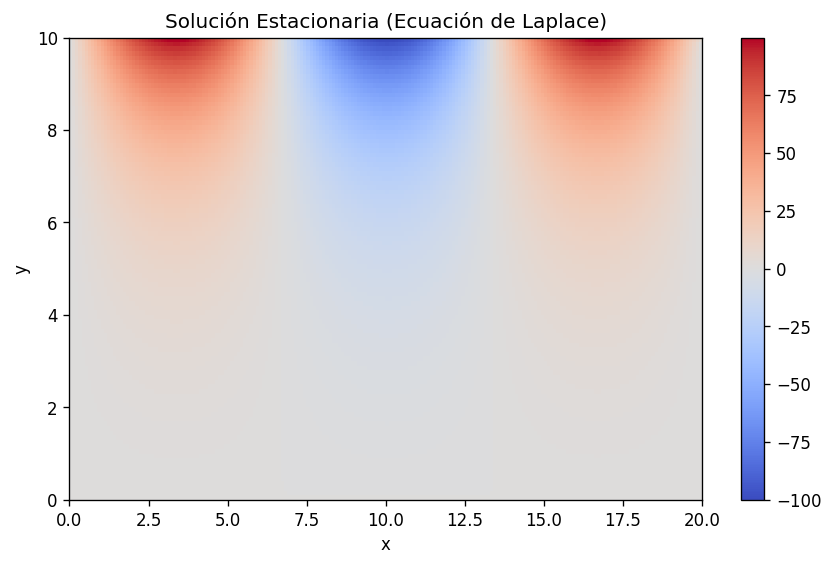

In [114]:
plt.figure(figsize=(8.5, 5))
plt.title("Solución Estacionaria (Ecuación de Laplace)")
plt.imshow(
    u_estatico.T,
    origin="lower",
    cmap="coolwarm",
    aspect="auto",
    extent=[x[0], x[-1], y[0], y[-1]],
)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

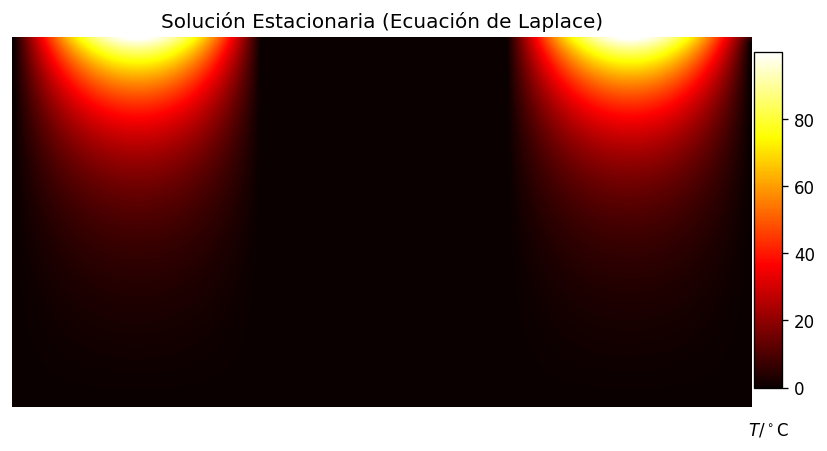

In [115]:
fig, ax = plt.subplots(figsize=(8, 4))

# Se aplica la transpuesta .T y origin='lower'
im = ax.imshow(
    u_estatico.T,
    cmap="hot",
    vmin=0,
    vmax=np.max(U_ini),
    interpolation="bilinear",
    origin="lower",
)

ax.set_axis_off()
ax.set_title(f"Solución Estacionaria (Ecuación de Laplace)")

cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel(r"$T / ^\circ\mathrm{C}$", labelpad=20)
fig.colorbar(im, cax=cbar_ax)

plt.show()

## Punto 2 — Comparación con la solución analítica

Para estas condiciones de frontera, la solución analítica es

$$
T(x,y)
=
100\sin\left(\frac{3\pi x}{a}\right)
\frac{
\sinh\left(\frac{3\pi y}{a}\right)
}{
\sinh\left(\frac{3\pi b}{a}\right)
}.
$$

In [130]:
# Solución Analitca
def Analitica(X,Y,a,b):
    return 100*np.sin((3*np.pi*X)/a)*((np.sinh((3*np.pi*Y)/a))/(np.sinh((3*np.pi*b)/a)))

In [131]:
x = np.linspace(0, a, nx)
y = np.linspace(0, b, ny)
X, Y = np.meshgrid(x, y, indexing="ij")
U_analitica = Analitica(X, Y, a, b)

In [132]:
# Diferencia entre FDM y solución analítica
error = np.abs(u_estatico - U_analitica)

print("Error máximo =", np.max(error), "°C")
print("Error medio =", np.mean(error), "°C")

Error máximo = 4.710645070964151 °C
Error medio = 0.3150990892458706 °C


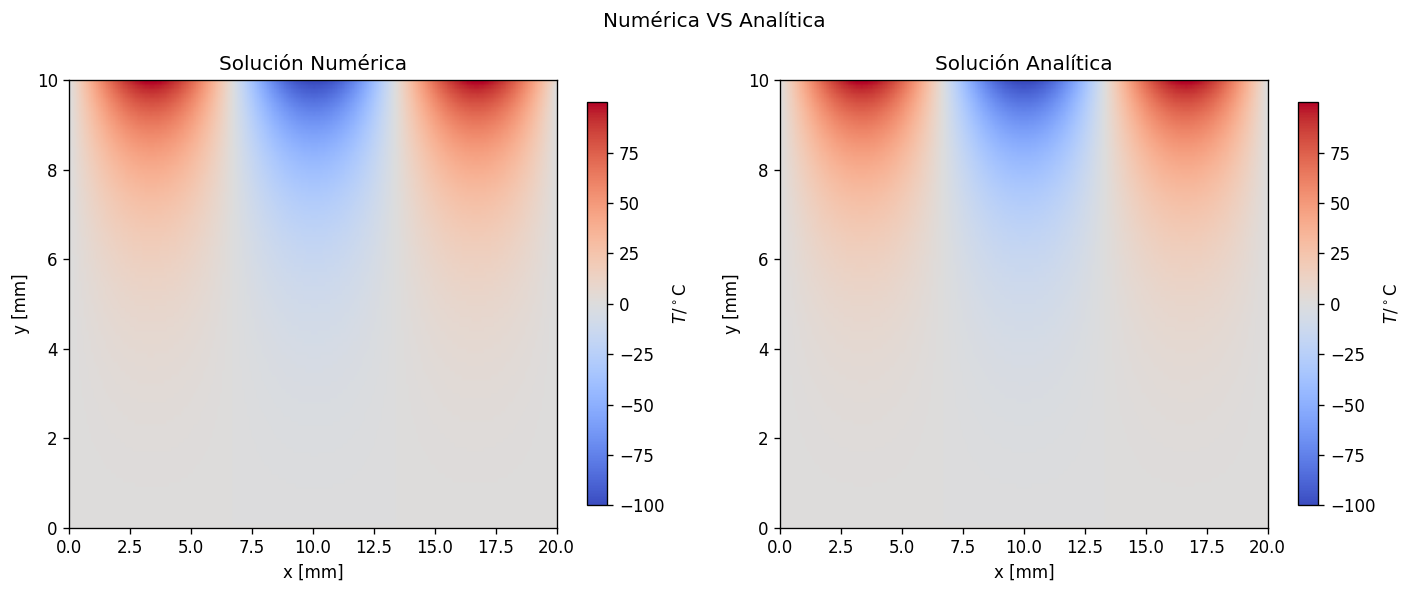

In [143]:
vmin = min(u_estatico.min(), U_analitica.min())
vmax = max(u_estatico.max(), U_analitica.max())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Numérica VS Analítica")

# Solución numérica
im1 = ax[0].imshow(
    u_estatico.T,
    origin="lower",
    extent=[0, a, 0, b],
    aspect="auto",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax
)

ax[0].set_title("Solución Numérica")
ax[0].set_xlabel("x [mm]")
ax[0].set_ylabel("y [mm]")

cbar1 = fig.colorbar(im1, ax=ax[0], shrink=0.9)
cbar1.set_label(r"$T / ^\circ\mathrm{C}$")


# Solución analítica
im2 = ax[1].imshow(
    U_analitica.T,
    origin="lower",
    extent=[0, a, 0, b],
    aspect="auto",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax
)

ax[1].set_title("Solución Analítica")
ax[1].set_xlabel("x [mm]")
ax[1].set_ylabel("y [mm]")

cbar2 = fig.colorbar(im2, ax=ax[1], shrink=0.9)
cbar2.set_label(r"$T / ^\circ\mathrm{C}$")

plt.tight_layout()
plt.show()

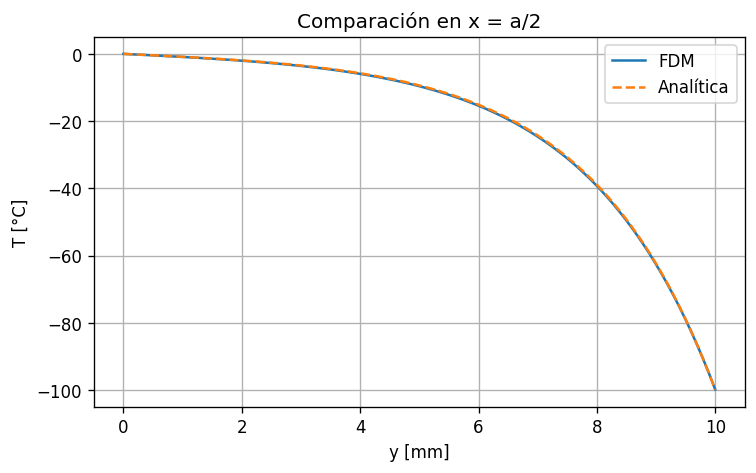

In [133]:
j = np.argmin(np.abs(x - a/2))

plt.figure(figsize=(7, 4))

plt.plot(
    y, u_estatico[j, :],
    label="FDM"
)

plt.plot(
    y, U_analitica[j, :],
    "--",
    label="Analítica"
)

plt.xlabel("y [mm]")
plt.ylabel("T [°C]")
plt.title("Comparación en x = a/2")
plt.grid()
plt.legend()
plt.show()

## Punto 3 — Difusión de la temperatura en el tiempo

La actualización explícita utilizada es

$$
T_{i,j}^{n+1}
=
T_{i,j}^{n}
+
D\Delta t
\left[
\frac{
T_{i+1,j}^{n}
-2T_{i,j}^{n}
+T_{i-1,j}^{n}
}{\Delta x^2}
+
\frac{
T_{i,j+1}^{n}
-2T_{i,j}^{n}
+T_{i,j-1}^{n}
}{\Delta y^2}
\right].
$$

La placa comienza a 0°C, excepto por la frontera superior, que permanece fijada por $f(x)$.

In [119]:
def diffusion_step(T):
    T_new = T.copy()

    T_new[1:-1, 1:-1] = (
        T[1:-1, 1:-1]
        + D*dt*(
            (T[2:, 1:-1] - 2*T[1:-1, 1:-1] + T[:-2, 1:-1])/dx2
            + (T[1:-1, 2:] - 2*T[1:-1, 1:-1] + T[1:-1, :-2])/dy2
        )
    )

    # Fronteras
    T_new[0, :] = 0
    T_new[-1, :] = 0
    T_new[:, 0] = 0
    T_new[:, -1] = 100*np.sin(3*np.pi*x/a)

    return T_new

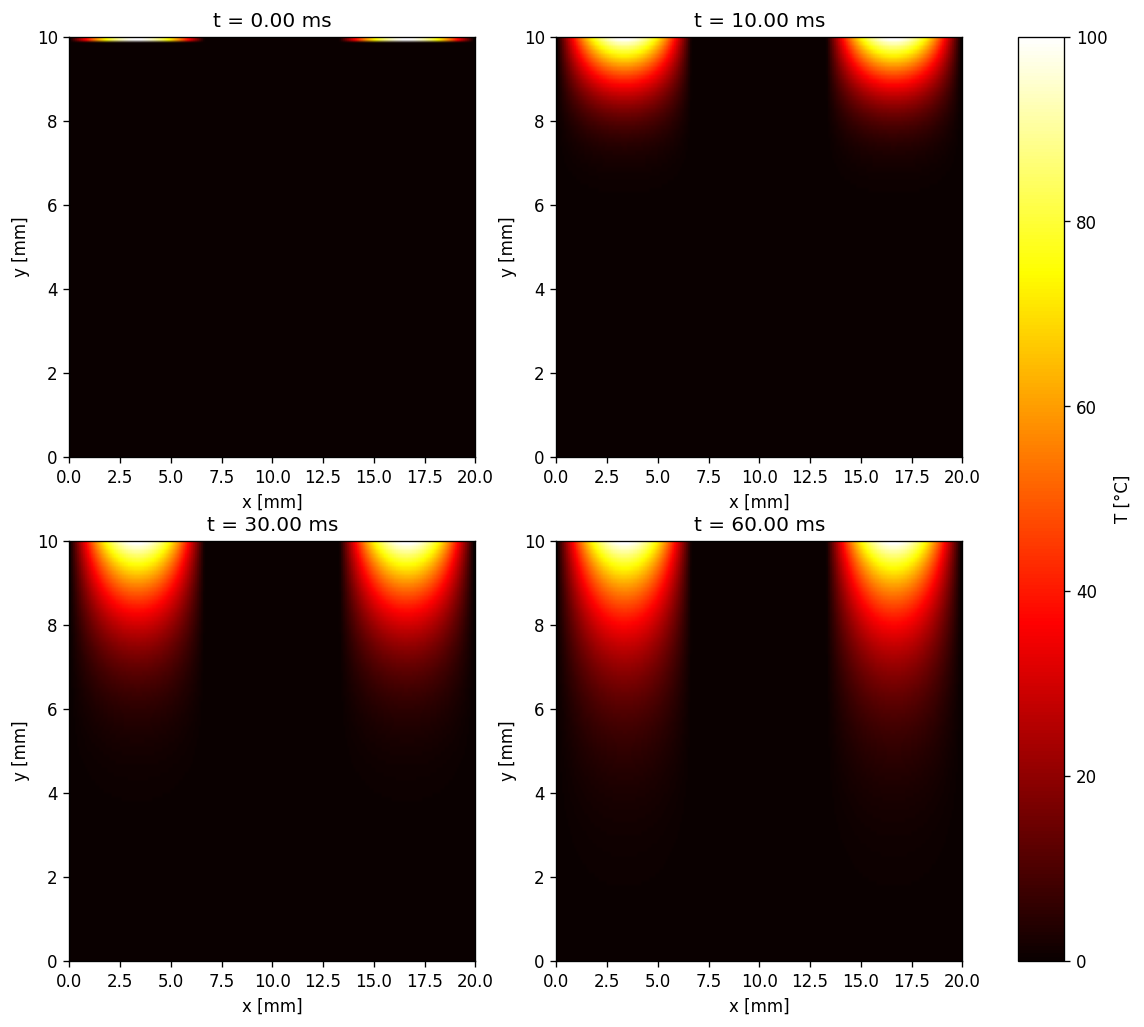

In [146]:
def solve_until(time):
    U = np.zeros((nx, ny))

    # Condición inicial
    U[:, -1] = 100*np.sin(3*np.pi*x/a)

    n = int(np.ceil(time/dt))

    for _ in range(n):
        U = diffusion_step(U)

    return U


times = [0, 0.01, 0.03, 0.06]

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

for axis, t in zip(ax.ravel(), times):
    U = solve_until(t)

    image = axis.imshow(
        U.T,
        origin="lower",
        extent=[0, a, 0, b],
        aspect="auto",
        cmap="hot",
        vmin=0,
        vmax=100
    )

    axis.set_title(f"t = {t*1000:.2f} ms")
    axis.set_xlabel("x [mm]")
    axis.set_ylabel("y [mm]")

fig.colorbar(image, ax=ax.ravel().tolist(), label="T [°C]")

plt.show()

## Punto 4 — GIF de la evolución temporal (bonus)

Se generan varios cuadros de la simulación y se unen en un GIF para visualizar cómo el calor se propaga desde la frontera superior hacia el interior de la placa.


GIF creado: temperatura_difusion.gif


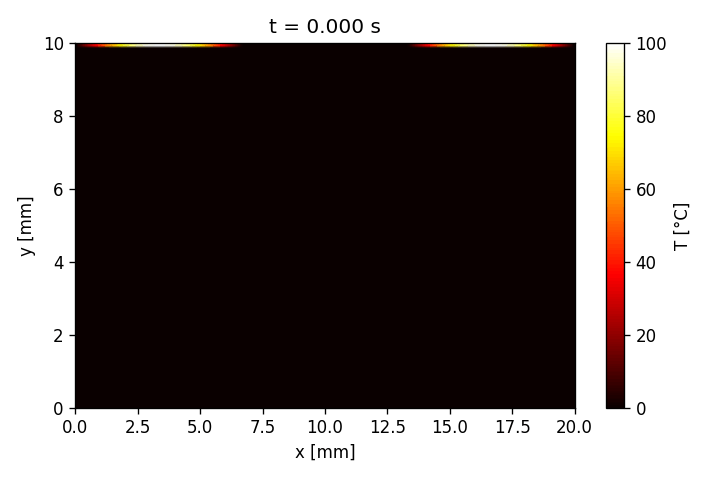

In [147]:
# Parámetros de la animación
t_total = 0.05
n_frames = 60

T_anim = np.zeros((nx, ny))
T_anim[:, -1] = 100*np.sin(3*np.pi*x/a)

frames = []
current_time = 0

for frame in range(n_frames):
    target_time = t_total*frame/(n_frames - 1)

    while current_time < target_time:
        T_anim = diffusion_step(T_anim)
        current_time += dt

    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(
        T_anim.T,
        origin="lower",
        extent=[0, a, 0, b],
        aspect="auto",
        cmap="hot",
        vmin=0,
        vmax=100
    )

    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
    ax.set_title(f"t = {target_time:.3f} s")
    fig.colorbar(im, ax=ax, label="T [°C]")
    plt.tight_layout()

    buffer = io.BytesIO()
    fig.savefig(buffer, format="png")
    buffer.seek(0)
    frames.append(Image.open(buffer).convert("RGB").copy())
    plt.close(fig)

frames[0].save(
    "temperatura_difusion.gif",
    save_all=True,
    append_images=frames[1:],
    duration=80,
    loop=0
)

print("GIF creado: temperatura_difusion.gif")
display(DisplayImage(filename="temperatura_difusion.gif"))

## Conclusión

La solución obtenida mediante FDM reproduce la distribución estacionaria de temperatura de la placa. La comparación con la solución analítica permite verificar el error numérico. En el problema dependiente del tiempo, la temperatura se propaga desde la frontera superior hacia el interior de la placa y, a medida que aumenta el tiempo, la distribución se aproxima al estado estacionario.